## **Step 1: Load and describe the College Message Network**

Number of nodes: 1899
Number of edges: 20296
Louvain found 14 communities


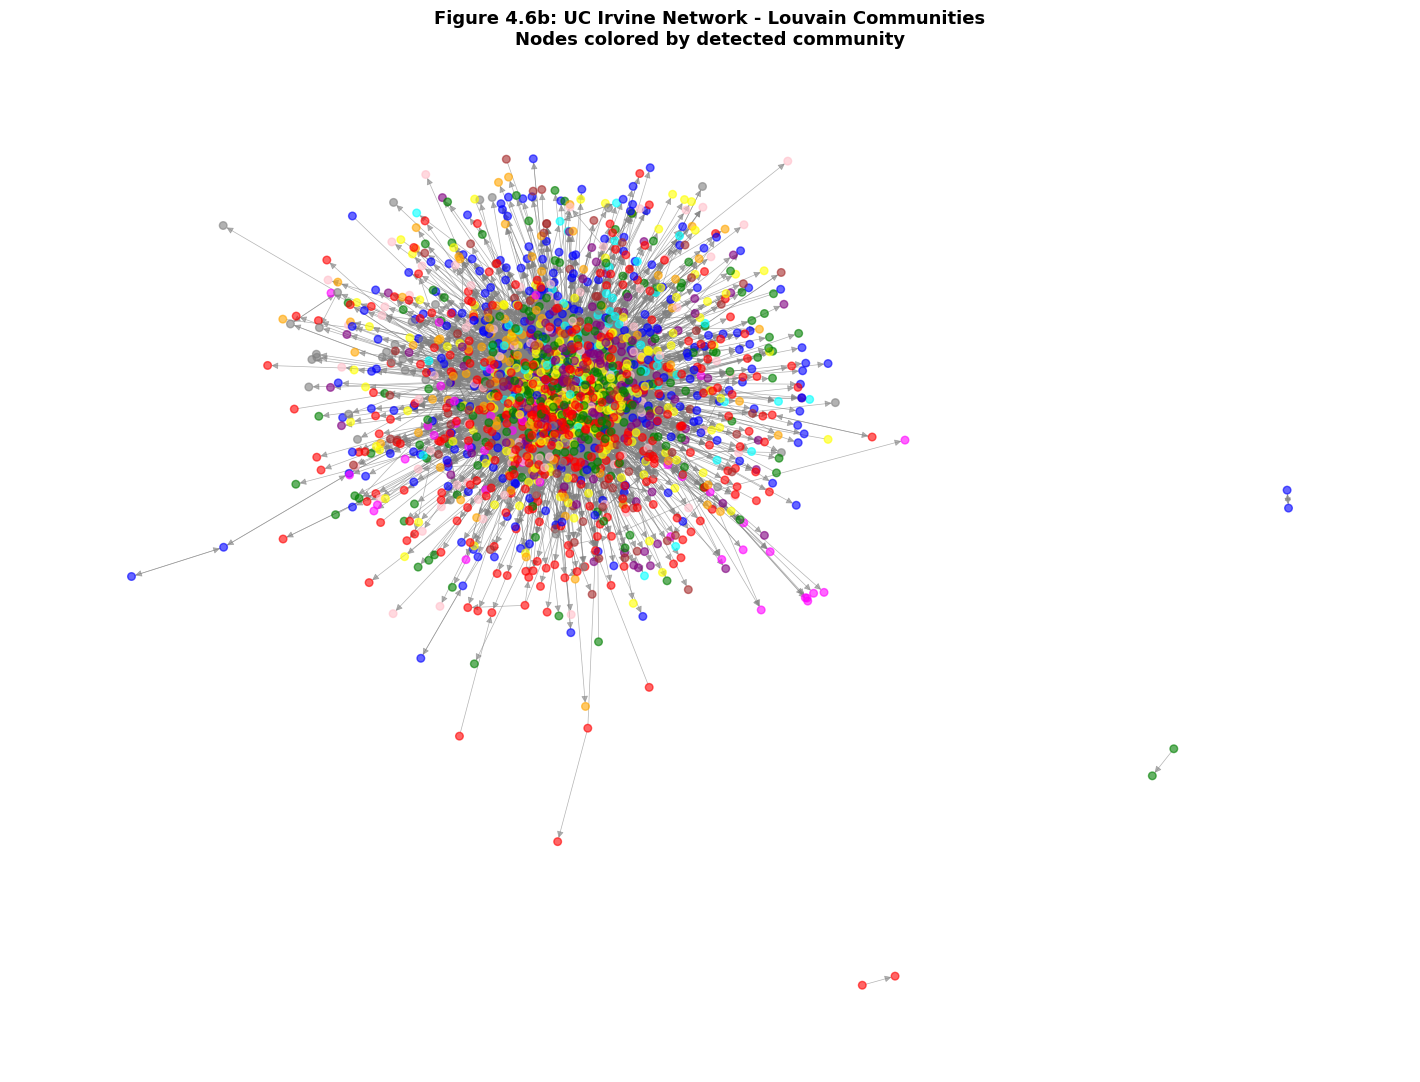

Figure saved


In [ ]:
!pip install cdlib
import networkx as nx
import matplotlib.pyplot as plt
import urllib.request
import gzip
import io
import random
import numpy as np
import cdlib
from cdlib import algorithms

# Reproducibility
random.seed(1)
np.random.seed(1)

# Download from SNAP
url = "https://snap.stanford.edu/data/CollegeMsg.txt.gz"
response = urllib.request.urlopen(url)
compressed_file = io.BytesIO(response.read())

with gzip.open(compressed_file, 'rt') as f:
    G_college = nx.read_edgelist(f, create_using=nx.DiGraph(),
                              comments="#",
                              data=[('timestamp', int)])

# Basic info
print(f"Number of nodes: {G_college.number_of_nodes()}")
print(f"Number of edges: {G_college.number_of_edges()}")

# Run Louvain to detect communities on an undirected version of the graph
louvain = algorithms.louvain(G_college.to_undirected())
print(f"Louvain found {len(louvain.communities)} communities")

# Map nodes to communities
node_to_community = {}
for community_id, community in enumerate(louvain.communities):
    for node in community:
        node_to_community[node] = community_id

# Simple colors
simple_colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'pink', 'brown', 'gray', 'cyan', 'magenta']
node_colors = [simple_colors[node_to_community[node] % len(simple_colors)] for node in G_college.nodes()]

# Visualize
pos = nx.spring_layout(G_college, seed=1, k=0.1)  # smaller k for large networks

plt.figure(figsize=(14, 10))
nx.draw(G_college, pos,
        with_labels=False,  # NO labels on large networks
        node_color=node_colors,
        node_size=30,  # smaller nodes
        edge_color="gray",
        alpha=0.6,
        width=0.5)

plt.title("Figure 4.6b: UC Irvine Network - Louvain Communities\nNodes colored by detected community",
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('figure_4_6b_college_communities.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved")

## **Step 2: Degree Analysis**

In [ ]:
# Out-degree: how many people each user SENDS messages to
out_degrees = dict(G_college.out_degree())
avg_out_degree = sum(out_degrees.values()) / len(out_degrees)

# In-degree: how many people SEND messages to each user
in_degrees = dict(G_college.in_degree())
avg_in_degree = sum(in_degrees.values()) / len(in_degrees)

# Total degree
total_degree = {node: in_degrees[node] + out_degrees[node] for node in G_college.nodes()}

print(f"Average out-degree (messages sent): {avg_out_degree:.2f}")
print(f"Average in-degree (messages received): {avg_in_degree:.2f}")
print(f"Max out-degree: {max(out_degrees.values())}")
print(f"Max in-degree: {max(in_degrees.values())}")

Average out-degree (messages sent): 10.69
Average in-degree (messages received): 10.69
Max out-degree: 237
Max in-degree: 137


## **Step 3: Degree distribution plots**

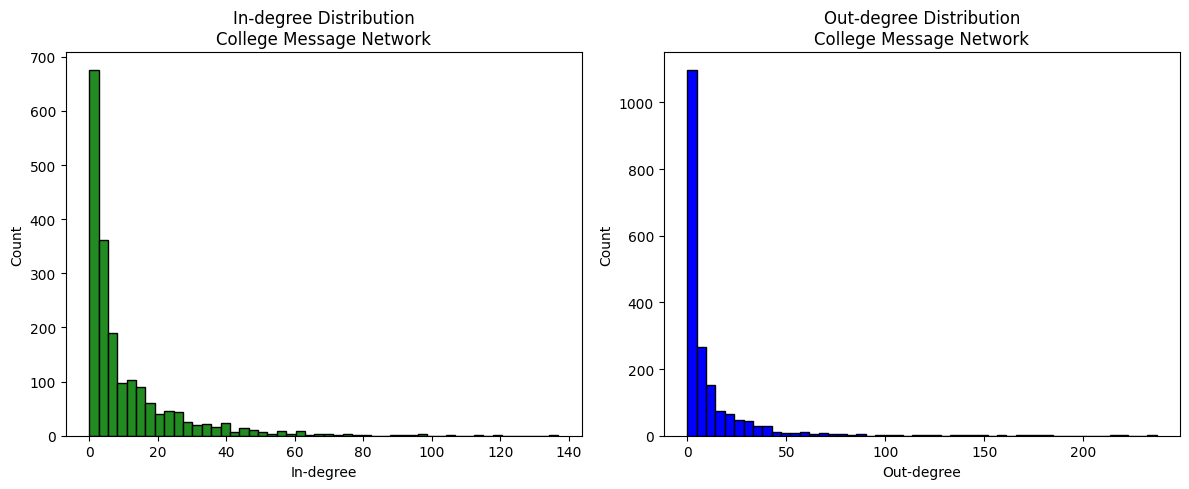

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # pattern of 2 plots

# in-degree distribution
in_degree_values = list(in_degrees.values())
axes[0].hist(in_degree_values, bins=50,
             color="forestgreen", edgecolor="black")
axes[0].set_title("In-degree Distribution\nCollege Message Network")
axes[0].set_xlabel("In-degree")
axes[0].set_ylabel("Count")

# out-degree distribution
out_deg_values = list(out_degrees.values())
axes[1].hist(out_deg_values, bins=50,
             color="blue", edgecolor="black")
axes[1].set_title("Out-degree Distribution\nCollege Message Network")
axes[1].set_xlabel("Out-degree")
axes[1].set_ylabel("Count")

# visualize
plt.tight_layout()
plt.savefig('figure_4_6a_college_in_out_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## **Step 4: Community Detection**

In [ ]:
!pip install cdlib
from cdlib import algorithms, evaluation

# create a proper undirected copy
G_college_undirected = G_college.to_undirected()

# verify
print(f"Directed version - Is directed: {G_college.is_directed()}")
print(f"Undirected version - Is directed: {G_college_undirected.is_directed()}")

# run three methods on the subgraph weak component
louvain_college = algorithms.louvain(G_college_undirected)
infomap_college = algorithms.infomap(G_college) # Infomap can work with directed graphs
walktrap_college = algorithms.walktrap(G_college_undirected)

# print number of communities found
print(f"\nLouvain: {len(louvain_college.communities)} communities found")
print(f"Infomap: {len(infomap_college.communities)} communities found")
print(f"Walktrap: {len(walktrap_college.communities)} communities found")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.6/263.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 62.1 MB/s eta 0:00:00
Note: to be able to use all crisp methods, you need to install some additional packages:  {'bayanpy', 'infomap', 'leidenalg', 'graph_tool', 'wurlitzer'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'leidenalg', 'wurlitzer'}
Directed version - Is directed: True
Undirected version - Is directed: False

Louvain: 14 communities found
Infomap: 58 communities found
Walktrap: 529 communities found


## **Step 5: Change the Walktrap with Leiden**

In [ ]:
!pip install igraph leidenalg
leiden_college = algorithms.leiden(G_college_undirected)

print(f"Leiden: {len(leiden_college.communities)} communities found")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 19.8 MB/s eta 0:00:00
Leiden: 13 communities found


## **Step 6: Check the community sizes**

In [ ]:
from cdlib import algorithms, evaluation


label_wiki = algorithms.label_propagation(G_college_undirected)

for name, method in [("Louvain", louvain_college),
                   ("Infomap", infomap_college),
                   ("Leiden", leiden_college)]:
    sizes = sorted([len(community) for community in method.communities],
            reverse=True)

    print(f"{name}:")
    print(f"Number of communities: {len(sizes)}")
    print(f"Largest community size: {sizes[0]}")
    print(f"Smallest community size: {sizes[-1]}")
    print(f"Average community size: {sum(sizes) / len(sizes):.1f}")

Louvain:
Number of communities: 14
Largest community size: 393
Smallest community size: 2
Average community size: 135.6
Infomap:
Number of communities: 58
Largest community size: 1551
Smallest community size: 2
Average community size: 32.7
Leiden:
Number of communities: 13
Largest community size: 386
Smallest community size: 2
Average community size: 146.1


In [ ]:
import networkx.algorithms.community as nx_comm

# compute modularity for each method
# we need to convert communities to sets first
louvain_sets = [set(c) for c in louvain_college.communities]
leiden_sets  = [set(c) for c in leiden_college.communities]
infomap_sets = [set(c) for c in infomap_college.communities]

# modularity works on undirected graphs
mod_louvain = nx_comm.modularity(G_college_undirected, louvain_sets)
mod_leiden  = nx_comm.modularity(G_college_undirected, leiden_sets)
mod_infomap = nx_comm.modularity(G_college_undirected, infomap_sets)

print(f"Modularity Louvain:  {mod_louvain:.4f}")
print(f"Modularity Leiden:   {mod_leiden:.4f}")
print(f"Modularity Infomap:  {mod_infomap:.4f}")

Modularity Louvain:  0.2484
Modularity Leiden:   0.2662
Modularity Infomap:  0.0477


Saved: figure_47_1_communities


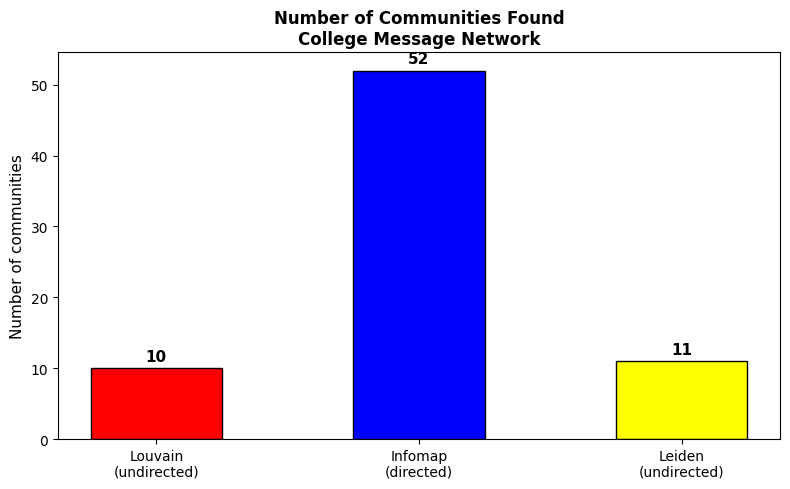

Saved: figure_47_2_modularity


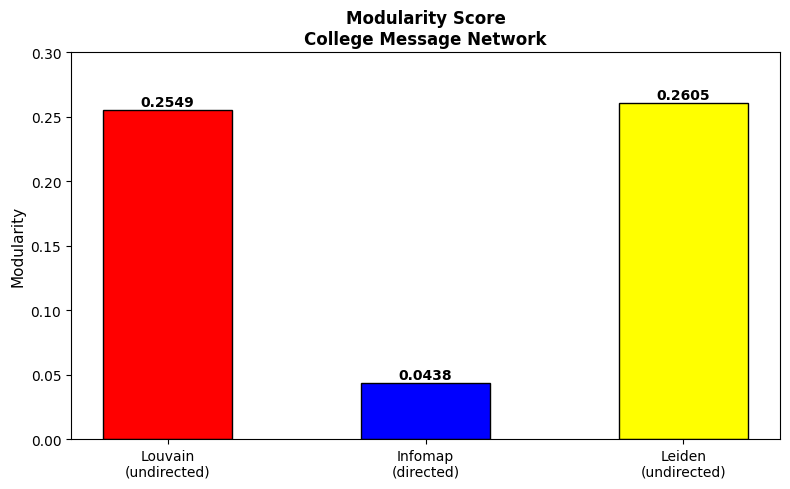

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:


import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

# Data
methods = ["Louvain\n(undirected)",
           "Infomap\n(directed)",
           "Leiden\n(undirected)"]
communities = [10, 52, 11]
modularities = [0.2549, 0.0438, 0.2605]

# FIGURE 1: Communities
fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(methods, communities,
        color=["red", "blue", "yellow"],
        edgecolor="black", width=0.5)
ax1.set_title("Number of Communities Found\nCollege Message Network", fontsize=12, fontweight="bold")
ax1.set_ylabel("Number of communities", fontsize=11)
for i, v in enumerate(communities):
    ax1.text(i, v + 1, str(v), ha="center", fontweight="bold", fontsize=11)
plt.tight_layout()
fig1.savefig('figures/figure_4_6_1_communities.png', dpi=300, bbox_inches='tight')
fig1.savefig('figures/figure_4_6_1_communities.pdf', bbox_inches='tight')
print("Saved: figure_47_1_communities")
plt.show()

# FIGURE 2: Modularity
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.bar(methods, modularities,
        color=["red", "blue", "yellow"],
        edgecolor="black", width=0.5)
ax2.set_title("Modularity Score\nCollege Message Network", fontsize=12, fontweight="bold")
ax2.set_ylabel("Modularity", fontsize=11)
ax2.set_ylim(0, 0.30)
for i, v in enumerate(modularities):
    ax2.text(i, v + 0.003, f"{v:.4f}", ha="center", fontweight="bold", fontsize=10)
plt.tight_layout()
fig2.savefig('figures/figure_4_6_2_modularity.png', dpi=300, bbox_inches='tight')
fig2.savefig('figures/figure_4_6_2_modularity.pdf', bbox_inches='tight')
print("Saved: figure_47_2_modularity")
plt.show()

# Download both
from google.colab import files
files.download('figures/figure_4_6_1_communities.png')
files.download('figures/figure_4_6_2_modularity.png')